# Bivariate Analysis

This notebook studies the relationship between key features and the fraud target. The goal is to identify which variables show meaningful separation between legitimate and fraudulent transactions and which relationships may improve model performance.

## 1. Objectives

This notebook focuses on the following tasks:

- compare important features across the fraud target classes
- study how `Amount` and `Time` behave for fraud and non-fraud transactions
- inspect class-wise feature distributions for selected PCA variables
- summarize which features show stronger separation from the target
- save bivariate tables, figures, and a markdown report for later modeling decisions

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.append(str(Path("..").resolve()))

from src.config import AMOUNT_COLUMN, PCA_COLUMNS, PROJECT_ROOT, TARGET_COLUMN, TIME_COLUMN
from src.data.data_loader import load_cleaned_data

NOTEBOOK_TABLES_DIR = PROJECT_ROOT / "reports" / "tables" / "06_bivariate_analysis"
NOTEBOOK_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "06_bivariate_analysis"
NOTEBOOK_TABLES_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

print("Imports OK")
print(f"  Target column : {TARGET_COLUMN}")
print(f"  Tables dir    : {NOTEBOOK_TABLES_DIR}")
print(f"  Figures dir   : {NOTEBOOK_FIGURES_DIR}")

Imports OK
  Target column : Class
  Tables dir    : /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/06_bivariate_analysis
  Figures dir   : /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/06_bivariate_analysis


## 2. Load Cleaned Data

In [2]:
df = load_cleaned_data()

print("Cleaned dataset shape:", df.shape)
df.head()

Cleaned dataset shape: (283726, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Amount vs Class

In [3]:
amount_by_class = df.groupby(TARGET_COLUMN)[AMOUNT_COLUMN].agg(["count", "mean", "median", "std", "min", "max"]).round(4)
amount_by_class.to_csv(NOTEBOOK_TABLES_DIR / "amount_by_class_summary.csv")
amount_by_class

,count,mean,median,std,min,max
Class,,,,,,
0,283253,88.4136,22.00,250.379,0.0,25691.16
1,473,123.8719,9.82,260.211,0.0,2125.87


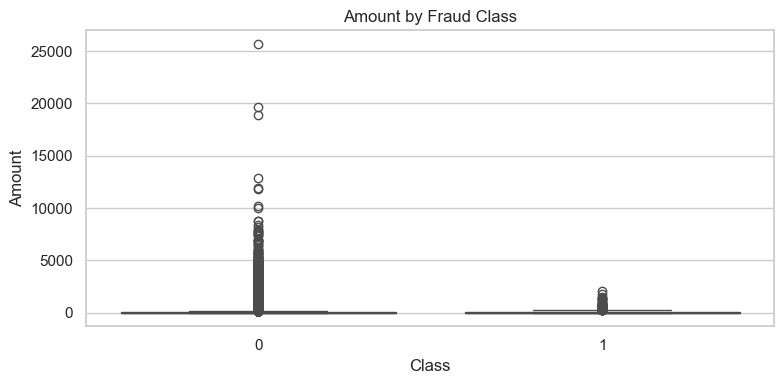

In [4]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x=TARGET_COLUMN, y=AMOUNT_COLUMN)
plt.title("Amount by Fraud Class")
plt.xlabel("Class")
plt.ylabel("Amount")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / "amount_by_class_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

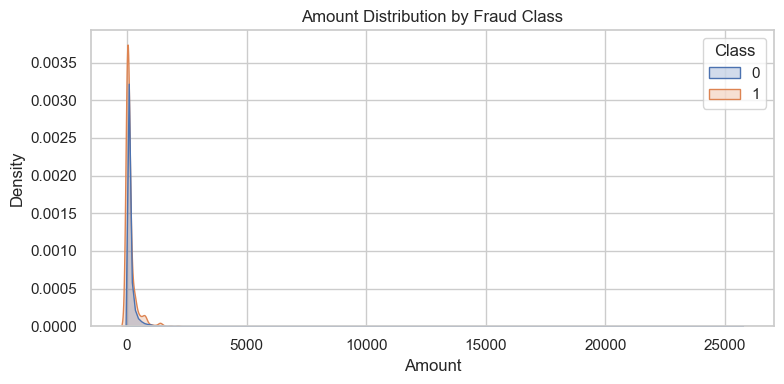

In [5]:
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x=AMOUNT_COLUMN, hue=TARGET_COLUMN, common_norm=False, fill=True)
plt.title("Amount Distribution by Fraud Class")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / "amount_by_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Time vs Class

In [6]:
time_by_class = df.groupby(TARGET_COLUMN)[TIME_COLUMN].agg(["count", "mean", "median", "std", "min", "max"]).round(4)
time_by_class.to_csv(NOTEBOOK_TABLES_DIR / "time_by_class_summary.csv")
time_by_class

,count,mean,median,std,min,max
Class,,,,,,
0,283253,94835.0581,84711.0,47475.5506,0.0,172792.0
1,473,80450.5137,73408.0,48636.1800,406.0,170348.0


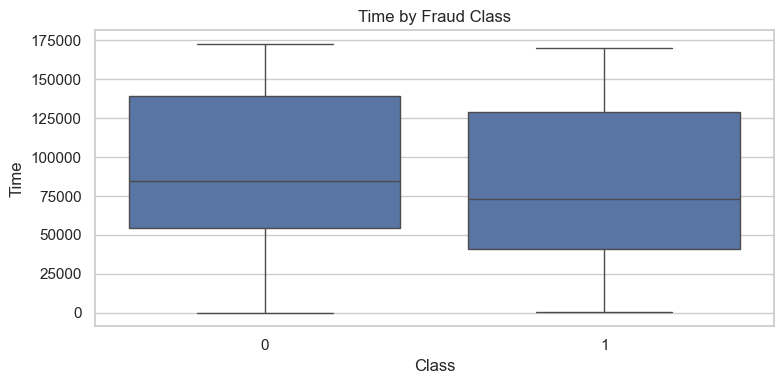

In [7]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x=TARGET_COLUMN, y=TIME_COLUMN)
plt.title("Time by Fraud Class")
plt.xlabel("Class")
plt.ylabel("Time")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / "time_by_class_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

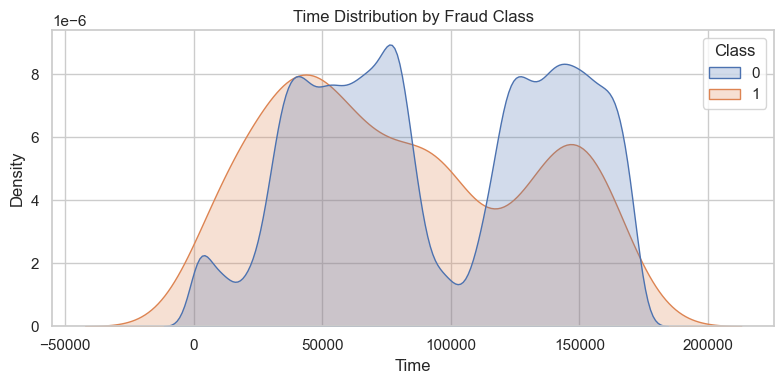

In [8]:
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x=TIME_COLUMN, hue=TARGET_COLUMN, common_norm=False, fill=True)
plt.title("Time Distribution by Fraud Class")
plt.xlabel("Time")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / "time_by_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. PCA Features vs Class

In [9]:
selected_pca_features = PCA_COLUMNS[:6]
pca_class_summary_frames = []

for feature in selected_pca_features:
    summary = df.groupby(TARGET_COLUMN)[feature].agg(["mean", "median", "std"]).round(4)
    summary.insert(0, "feature", feature)
    pca_class_summary_frames.append(summary.reset_index())

pca_class_summary = pd.concat(pca_class_summary_frames, ignore_index=True)
pca_class_summary.to_csv(NOTEBOOK_TABLES_DIR / "selected_pca_by_class_summary.csv", index=False)
pca_class_summary

,Class,feature,mean,median,std
0,0,V1,0.0134,0.0226,1.9222
1,1,V1,-4.4983,-2.2718,6.5931
2,0,V2,-0.0098,0.0626,1.6335
3,1,V2,3.4060,2.6171,4.1225
4,0,V3,0.0129,0.1822,1.4576
5,1,V3,-6.7296,-4.8754,6.9096
6,0,V4,-0.0104,-0.0245,1.3986
7,1,V4,4.4726,4.1001,2.8715
8,0,V5,0.0068,-0.0528,1.3558
9,1,V5,-2.9572,-1.3722,5.2788


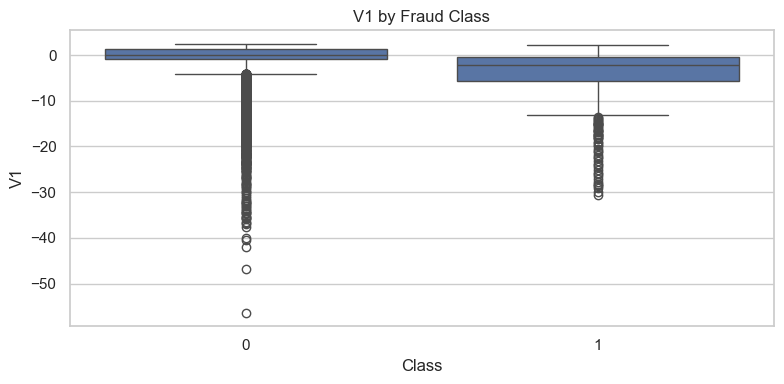

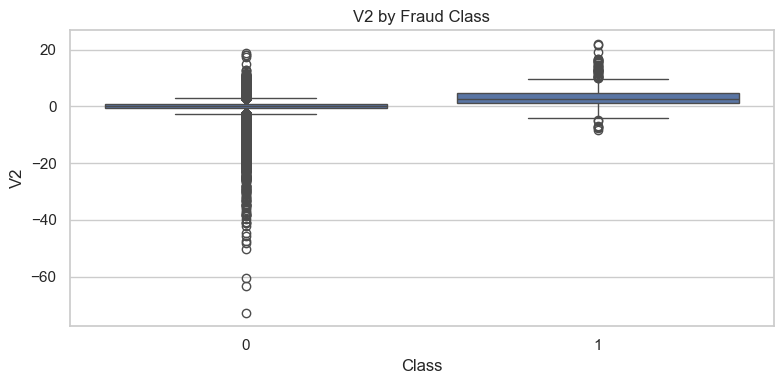

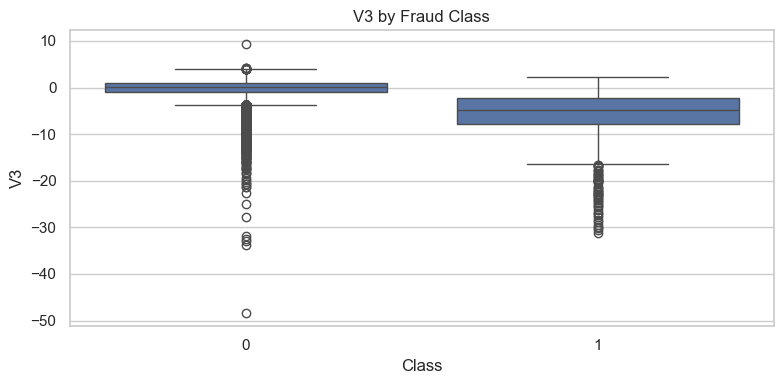

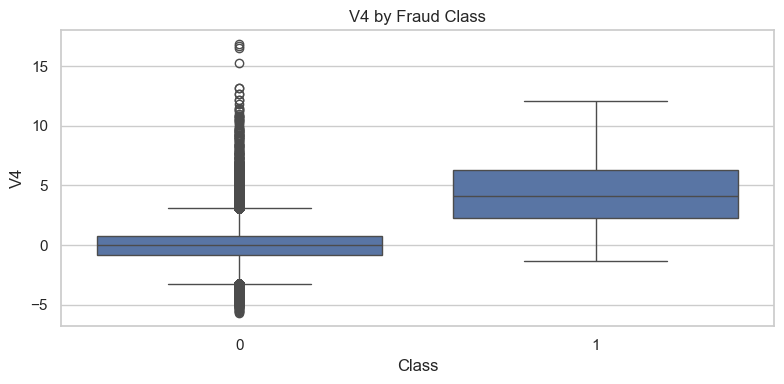

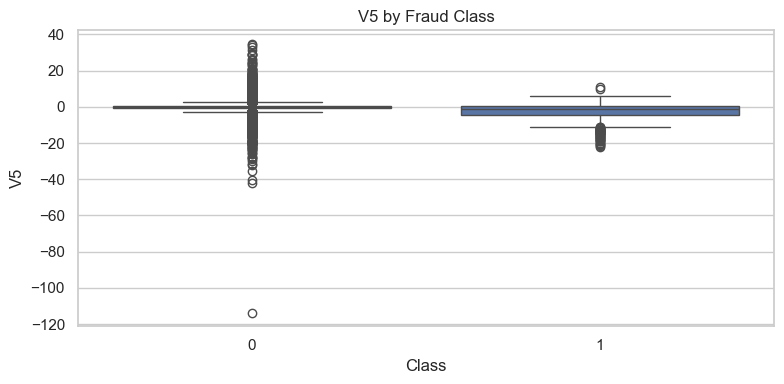

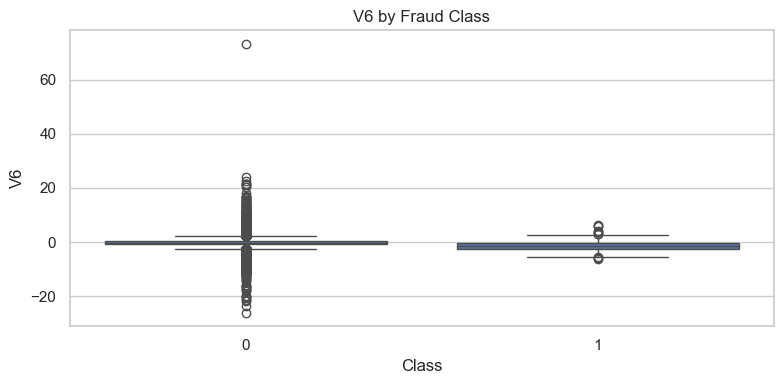

In [10]:
for feature in selected_pca_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=TARGET_COLUMN, y=feature)
    plt.title(f"{feature} by Fraud Class")
    plt.xlabel("Class")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.savefig(NOTEBOOK_FIGURES_DIR / f"{feature.lower()}_by_class_boxplot.png", dpi=300, bbox_inches="tight")
    plt.show()

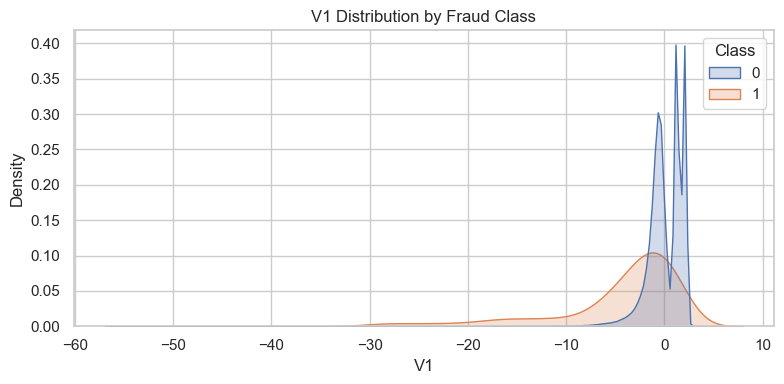

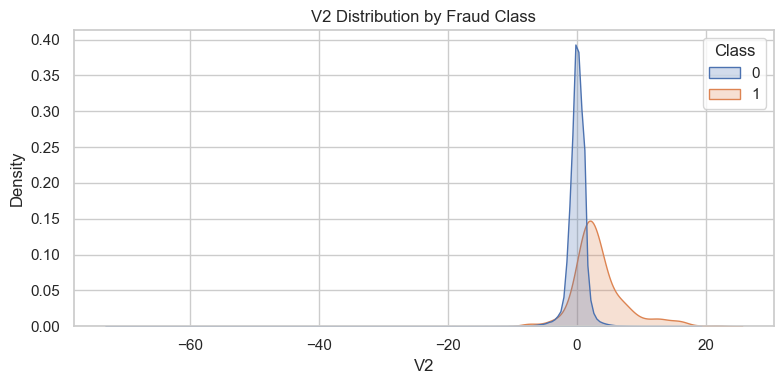

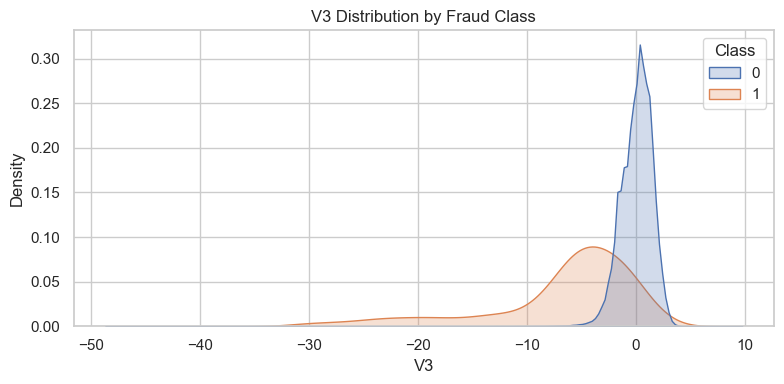

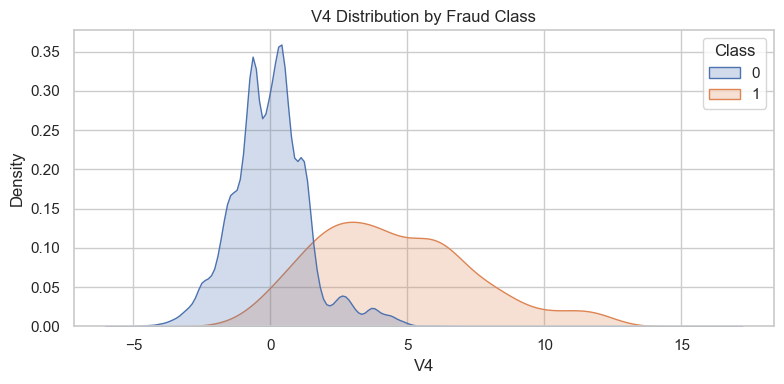

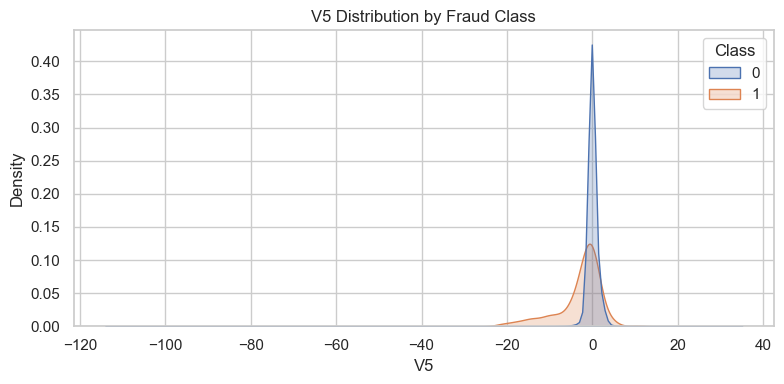

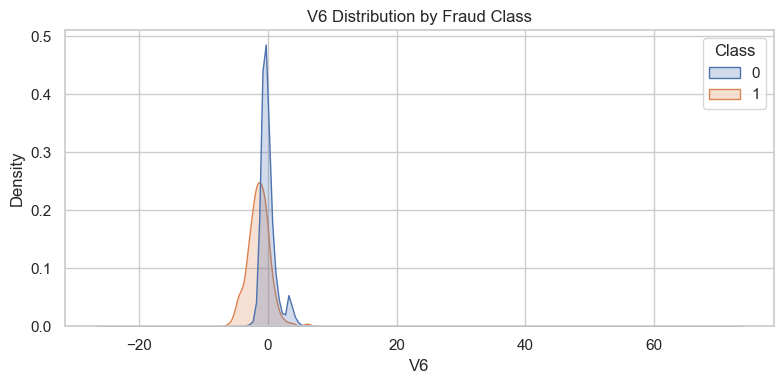

In [11]:
for feature in selected_pca_features:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=df, x=feature, hue=TARGET_COLUMN, common_norm=False, fill=True)
    plt.title(f"{feature} Distribution by Fraud Class")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.savefig(NOTEBOOK_FIGURES_DIR / f"{feature.lower()}_by_class_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

## 6. Feature Relationship with Target

In [12]:
correlation_with_target = df[[TIME_COLUMN, AMOUNT_COLUMN, *PCA_COLUMNS, TARGET_COLUMN]].corr(numeric_only=True)[[TARGET_COLUMN]].drop(index=TARGET_COLUMN)
correlation_with_target = correlation_with_target.rename(columns={TARGET_COLUMN: "correlation_with_class"}).sort_values("correlation_with_class", ascending=False)
correlation_with_target.to_csv(NOTEBOOK_TABLES_DIR / "correlation_with_target.csv")
correlation_with_target.head(10)

,correlation_with_class
V11,0.149067
V4,0.129326
V2,0.084624
V19,0.033631
V8,0.033068
V21,0.026357
V27,0.021892
V20,0.021486
V28,0.009682
Amount,0.005777


/var/folders/1l/ddpthpdj6j75gsq02qk0x0kc0000gn/T/ipykernel_30613/4199314061.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_correlations["correlation_with_class"], y=top_correlations.index, palette="vlag")


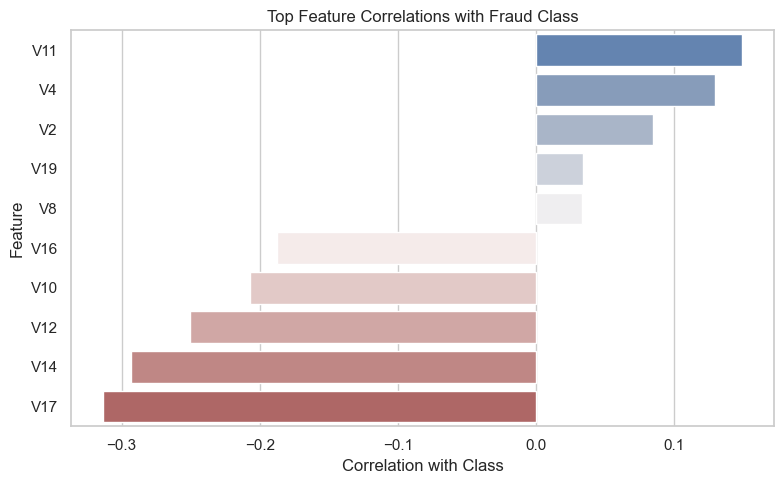

In [13]:
top_positive = correlation_with_target.head(5)
top_negative = correlation_with_target.tail(5)
top_correlations = pd.concat([top_positive, top_negative])

plt.figure(figsize=(8, 5))
sns.barplot(x=top_correlations["correlation_with_class"], y=top_correlations.index, palette="vlag")
plt.title("Top Feature Correlations with Fraud Class")
plt.xlabel("Correlation with Class")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / "top_feature_correlations_with_class.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Bivariate Interpretation

- `Amount` should be compared carefully across classes because differences in spread or extreme-value behavior may contribute to fraud separation.
- `Time` may provide supporting signal if fraud events appear concentrated in specific parts of the transaction timeline.
- PCA features that show stronger class-wise shifts or correlations with the target may be more useful for model discrimination.
- Bivariate analysis helps identify variables that deserve deeper attention in multivariate analysis and model-building stages.

## 8. Key Insights

- **Amount vs class:** Differences in the class-wise amount distribution may indicate that transaction size contributes to fraud risk, especially when combined with transformation and thresholding.
- **Time vs class:** Time-related patterns are more likely to be useful as contextual signals rather than standalone fraud rules.
- **PCA feature separation:** Selected PCA features should be reviewed for visible class separation because they may capture abnormal transactional structure beyond raw monetary behavior.
- **Target relationship:** Features with stronger positive or negative correlation with `Class` deserve priority in later modeling and interpretation steps.
- **Model readiness:** Bivariate patterns help decide which features are most promising for multivariate analysis, feature engineering, and class-aware model evaluation.

In [ ]:
bivariate_report = """# Bivariate Analysis Report

## Key Findings

- `Amount` and `Time` should be evaluated against the fraud target because they are the most directly interpretable variables in the dataset.
- Selected PCA features may show clearer separation between fraud and non-fraud classes than raw variables alone.
- Class-wise distribution differences provide useful evidence for feature selection and modeling priorities.

## Bivariate Interpretation

- Differences in class-wise amount behavior may strengthen fraud detection once the feature is transformed appropriately.
- Time patterns are more likely to act as supporting context than as standalone fraud triggers.
- PCA variables that shift more clearly by class may become strong inputs for supervised models.
- Correlation with `Class` should be treated as a screening signal, not a final feature-selection rule.

## Key Insights

- `Amount` may contribute to fraud separation through differences in spread and abnormal value behavior.
- `Time` may add supporting risk context when used with other features.
- PCA features that show stronger class-wise separation deserve priority in later modeling stages.
- Bivariate analysis improves model readiness by identifying which variables are more informative with respect to the fraud target.

## Saved Tables

- `reports/tables/06_bivariate_analysis/amount_by_class_summary.csv`
- `reports/tables/06_bivariate_analysis/time_by_class_summary.csv`
- `reports/tables/06_bivariate_analysis/selected_pca_by_class_summary.csv`
- `reports/tables/06_bivariate_analysis/correlation_with_target.csv`
- `reports/tables/06_bivariate_analysis/bivariate_report.md`

## Saved Figures

- `reports/figures/06_bivariate_analysis/amount_by_class_boxplot.png`
- `reports/figures/06_bivariate_analysis/amount_by_class_distribution.png`
- `reports/figures/06_bivariate_analysis/time_by_class_boxplot.png`
- `reports/figures/06_bivariate_analysis/time_by_class_distribution.png`
- `reports/figures/06_bivariate_analysis/v1_by_class_boxplot.png`
- `reports/figures/06_bivariate_analysis/v1_by_class_distribution.png`
- `reports/figures/06_bivariate_analysis/v2_by_class_boxplot.png`
- `reports/figures/06_bivariate_analysis/v2_by_class_distribution.png`
- `reports/figures/06_bivariate_analysis/v3_by_class_boxplot.png`
- `reports/figures/06_bivariate_analysis/v3_by_class_distribution.png`
- `reports/figures/06_bivariate_analysis/v4_by_class_boxplot.png`
- `reports/figures/06_bivariate_analysis/v4_by_class_distribution.png`
- `reports/figures/06_bivariate_analysis/v5_by_class_boxplot.png`
- `reports/figures/06_bivariate_analysis/v5_by_class_distribution.png`
- `reports/figures/06_bivariate_analysis/v6_by_class_boxplot.png`
- `reports/figures/06_bivariate_analysis/v6_by_class_distribution.png`
- `reports/figures/06_bivariate_analysis/top_feature_correlations_with_class.png`
"""

report_path = NOTEBOOK_TABLES_DIR / "bivariate_report.md"
report_path.write_text(bivariate_report, encoding="utf-8")
print(f"Bivariate report saved to: {report_path}")

## 9. Next Step

The next notebook should be `07_multivariate_analysis.ipynb`. It should examine combined feature relationships, broader correlation structure, and interaction patterns that may improve downstream modeling.